In [343]:
import numpy as np, awkward as ak, uproot, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [344]:
FILE = "/ceph/omunkombwe/fit__idea_o1_v03_60.root"
TREE = "events"

In [345]:
pt_bins = np.array([0.65, 0.72, 0.80, 0.90, 1.00, 1.15, 1.35, 1.60, 1.90, 2.30, 2.80, 3.40, 4.10, 5.00])
nhit_min = 54  # min shared hits to consider a track matched

In [346]:
# collectionIDs for fitted-track hit refs (all 5 subsystems)
CID = {
    'DCH_DigiCollection': np.uint32(3486206992),
    'VTXBDigis':          np.uint32(3128296108),
    'VTXDDigis':          np.uint32(3582560660),
    'SiWrBDigis':         np.uint32(1902269130),
    'SiWrDDigis':         np.uint32(3109826668),
}
COUNTABLE_CIDS = set(CID.values())  # purity denominator uses all five subsystems

In [347]:
with uproot.open(FILE) as f:
    t = f[TREE]
    arr = t.arrays([
        # ---- Truth (kinematics + vertex) ----
        "MCParticles.momentum.x","MCParticles.momentum.y","MCParticles.momentum.z",
        "MCParticles.PDG","MCParticles.generatorStatus",
        "MCParticles.vertex.x","MCParticles.vertex.y","MCParticles.vertex.z",

        # ---- Fitted tracks → flattened hit refs ----
        "Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_begin",
        "Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_end",
        "_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.index",
        "_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.collectionID",

        # ---- Sim links (digi ↔ sim ↔ MC) for ALL subdetectors ----
        "_DCH_DigiSimAssociationCollection_from.index",
        "_DCH_DigiSimAssociationCollection_to.index",
        "_DCHCollection_particle.index",

        "_VTXBSimDigiLinks_from/_VTXBSimDigiLinks_from.index",
        "_VTXBSimDigiLinks_to/_VTXBSimDigiLinks_to.index",
        "_VertexBarrelCollection_particle.index",

        "_VTXDSimDigiLinks_from/_VTXDSimDigiLinks_from.index",
        "_VTXDSimDigiLinks_to/_VTXDSimDigiLinks_to.index",
        "_VertexEndcapCollection_particle.index",

        "_SiWrBSimDigiLinks_from/_SiWrBSimDigiLinks_from.index",
        "_SiWrBSimDigiLinks_to/_SiWrBSimDigiLinks_to.index",
        "_SiWrBCollection_particle.index",

        "_SiWrDSimDigiLinks_from/_SiWrDSimDigiLinks_from.index",
        "_SiWrDSimDigiLinks_to/_SiWrDSimDigiLinks_to.index",
        "_SiWrDCollection_particle.index",
    ], how=dict)

In [348]:
mc_px, mc_py, mc_pz = arr["MCParticles.momentum.x"], arr["MCParticles.momentum.y"], arr["MCParticles.momentum.z"]
mc_pdg, mc_gen = arr["MCParticles.PDG"], arr["MCParticles.generatorStatus"]
mc_vx, mc_vy, mc_vz = arr["MCParticles.vertex.x"], arr["MCParticles.vertex.y"], arr["MCParticles.vertex.z"]

In [349]:
ft_beg  = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_begin"]
ft_end  = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_end"]
ft_idx  = arr["_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.index"]
ft_cid  = arr["_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.collectionID"]

In [350]:
# ---- Links (digis ↔ simhits ↔ MC)
DCH_from, DCH_to, DCH_sim2mc = arr["_DCH_DigiSimAssociationCollection_from.index"], arr["_DCH_DigiSimAssociationCollection_to.index"], arr["_DCHCollection_particle.index"]
VXB_from, VXB_to, VXB_sim2mc = arr["_VTXBSimDigiLinks_from/_VTXBSimDigiLinks_from.index"], arr["_VTXBSimDigiLinks_to/_VTXBSimDigiLinks_to.index"], arr["_VertexBarrelCollection_particle.index"]
VXD_from, VXD_to, VXD_sim2mc = arr["_VTXDSimDigiLinks_from/_VTXDSimDigiLinks_from.index"], arr["_VTXDSimDigiLinks_to/_VTXDSimDigiLinks_to.index"], arr["_VertexEndcapCollection_particle.index"]
SWB_from, SWB_to, SWB_sim2mc = arr["_SiWrBSimDigiLinks_from/_SiWrBSimDigiLinks_from.index"], arr["_SiWrBSimDigiLinks_to/_SiWrBSimDigiLinks_to.index"], arr["_SiWrBCollection_particle.index"]
SWD_from, SWD_to, SWD_sim2mc = arr["_SiWrDSimDigiLinks_from/_SiWrDSimDigiLinks_from.index"], arr["_SiWrDSimDigiLinks_to/_SiWrDSimDigiLinks_to.index"], arr["_SiWrDCollection_particle.index"]

In [351]:
# ---- Truth kinematics & selections ----
mc_pt = np.sqrt(mc_px**2 + mc_py**2)
is_mu = (abs(mc_pdg) == 13)
is_final = (mc_gen == 1)
R_prod = np.sqrt(mc_vx**2 + mc_vy**2)
from_ip = (R_prod < 50)  # mm  

In [352]:
# Majority-of-links digi→MC mapping (no weights)
# ==========================================================
def make_digi_to_mc_map(digi_from, digi_to_sim, sim_to_mc):
    """
    For each event:
      For each link (digi d -> simhit s):
         mc = sim_to_mc[s]
         acc[d][mc] += 1
      mapping[d] = argmax_mc acc[d][mc]
    """
    out = []
    for frm, to, sim2mc in zip(digi_from, digi_to_sim, sim_to_mc):
        acc = defaultdict(lambda: defaultdict(int))  # acc[d][mc] -> count
        for d, s in zip(ak.to_numpy(frm), ak.to_numpy(to)):
            if d is None or s is None or s < 0 or s >= len(sim2mc):
                continue
            mcid = sim2mc[s]
            if mcid is None or mcid < 0:
                continue
            acc[int(d)][int(mcid)] += 1
        # choose max-count MC per digi
        mapping = {}
        for d, bucket in acc.items():
            # deterministic tie-break: highest count, then largest mcid
            best_mcid, best_cnt = None, -1
            for mcid, cnt in bucket.items():
                if (cnt > best_cnt) or (cnt == best_cnt and (best_mcid is None or mcid > best_mcid)):
                    best_mcid, best_cnt = mcid, cnt
            mapping[int(d)] = best_mcid
        out.append(mapping)
    return out

In [353]:
# Build majority maps for all 5 subdetectors
dch_map = make_digi_to_mc_map(DCH_from, DCH_to, DCH_sim2mc)
vxb_map = make_digi_to_mc_map(VXB_from, VXB_to, VXB_sim2mc)
vxd_map = make_digi_to_mc_map(VXD_from, VXD_to, VXD_sim2mc)
swb_map = make_digi_to_mc_map(SWB_from, SWB_to, SWB_sim2mc)
swd_map = make_digi_to_mc_map(SWD_from, SWD_to, SWD_sim2mc)

In [354]:
#hit→MC for fitted-track hits
def hit_to_mc_for_event(evt, col_id, idx):
    if col_id == CID['DCH_DigiCollection']:
        return dch_map[evt].get(int(idx), None)
    if col_id == CID['VTXBDigis']:
        return vxb_map[evt].get(int(idx), None)
    if col_id == CID['VTXDDigis']:
        return vxd_map[evt].get(int(idx), None)
    if col_id == CID['SiWrBDigis']:
        return swb_map[evt].get(int(idx), None)
    if col_id == CID['SiWrDDigis']:
        return swd_map[evt].get(int(idx), None)
    

In [355]:
# SIM-HIT totals per MC across ALL five subdetectors (for hit-eff denominator)
# ==========================================================
def truth_simhits_all(evt):
    c = Counter()
    for mcid in ak.to_numpy(arr["_DCHCollection_particle.index"][evt]):
        if mcid is not None and mcid >= 0: c[int(mcid)] += 1
    for mcid in ak.to_numpy(arr["_VertexBarrelCollection_particle.index"][evt]):
        if mcid is not None and mcid >= 0: c[int(mcid)] += 1
    for mcid in ak.to_numpy(arr["_VertexEndcapCollection_particle.index"][evt]):
        if mcid is not None and mcid >= 0: c[int(mcid)] += 1
    for mcid in ak.to_numpy(arr["_SiWrBCollection_particle.index"][evt]):
        if mcid is not None and mcid >= 0: c[int(mcid)] += 1
    for mcid in ak.to_numpy(arr["_SiWrDCollection_particle.index"][evt]):
        if mcid is not None and mcid >= 0: c[int(mcid)] += 1
    return c


In [356]:
# ---------------- Binning tallies
den = np.zeros(len(pt_bins)-1)
num = np.zeros(len(pt_bins)-1)

In [357]:
# ---------------- Main events loop -----------------
n_events = len(mc_pt)
for evt in range(n_events):
    # truth preselection 
    mask_truth = (is_mu[evt]) & (is_final[evt]) & (from_ip[evt])
    if not ak.any(mask_truth):
        continue

    # SIM-HIT totals per MC (hit-eff denominator) and reconstructable set
    truth_hits_by_mc = truth_simhits_all(evt)

    truth_ids_evt = np.flatnonzero(ak.to_numpy(mask_truth))
    pts_evt = ak.to_numpy(mc_pt[evt])[ak.to_numpy(mask_truth)]

    recon_ids, recon_pts = [], []
    for tid, pt in zip(truth_ids_evt, pts_evt):
        if truth_hits_by_mc.get(int(tid), 0) >= nhit_min:
            recon_ids.append(int(tid))
            recon_pts.append(float(pt))
    if not recon_ids:
        continue

    # For each track, build contribution counts via majority digi→MC mapping
    beg_evt, end_evt = ft_beg[evt], ft_end[evt]
    idx_flat, col_flat = ft_idx[evt], ft_cid[evt]

    candidates = []  # (truth_id, shared, purity, hit_eff)
    for b, e in zip(beg_evt, end_evt):
        if b is None or e is None or e <= b:
            continue
        ids  = idx_flat[b:e]
        cols = col_flat[b:e]

        total_track_hits = 0
        contrib = Counter()  # hits on this track coming from each MC

        for idx_val, col_val in zip(ids, cols):
            if idx_val is None or col_val is None:
                continue
            col_val = np.uint32(col_val)
            if col_val not in COUNTABLE_CIDS:
                continue
            total_track_hits += 1
            mcid = hit_to_mc_for_event(evt, col_val, int(idx_val))
            if mcid is not None:
                contrib[mcid] += 1

        if total_track_hits == 0 or not contrib:
            continue

        best_mcid, shared = contrib.most_common(1)[0]
        purity = shared / float(total_track_hits)

        truth_total = float(truth_hits_by_mc.get(best_mcid, 0))  # SIM-HITS denominator
        hit_eff = (shared / truth_total) if truth_total > 0 else 0.0

        # ===== Definition 2 thresholds =====
        if (purity >= 0.66) and (hit_eff >= 0.05) and (shared >= nhit_min):
            candidates.append((best_mcid, shared, purity, hit_eff))



    # ====================================
    # one-to-one truth↔track: keep the candidate with largest 'shared'
    best_by_truth = {}
    for mcid, shared, pur, hef in candidates:
        if (mcid not in best_by_truth) or (shared > best_by_truth[mcid][0]):
            best_by_truth[mcid] = (shared, pur, hef)

    matched_truth_ids = set(best_by_truth.keys())

    # fill num/den by pT bins for reconstructable truths
    bins_idx = np.digitize(recon_pts, pt_bins) - 1
    for tid, b in zip(recon_ids, bins_idx):
        if 0 <= b < len(den):
            den[b] += 1
            if tid in matched_truth_ids:
                num[b] += 1
# ---------------- End of events loop -----------------

In [358]:
# Wald interval (~68%)
eff, err_wald = [], []
Z = 1.0
for k, n in zip(num, den):
    if n == 0:
        eff.append(np.nan); err_wald.append(np.nan); continue
    p_hat = k / n
    sigma = math.sqrt(max(p_hat*(1.0 - p_hat)/n, 0.0))
    eff.append(p_hat)
    err_wald.append(Z * sigma)


In [359]:
# ---------------- Plots
centers = 0.5*(pt_bins[:-1] + pt_bins[1:])
xerr = np.diff(pt_bins)/2


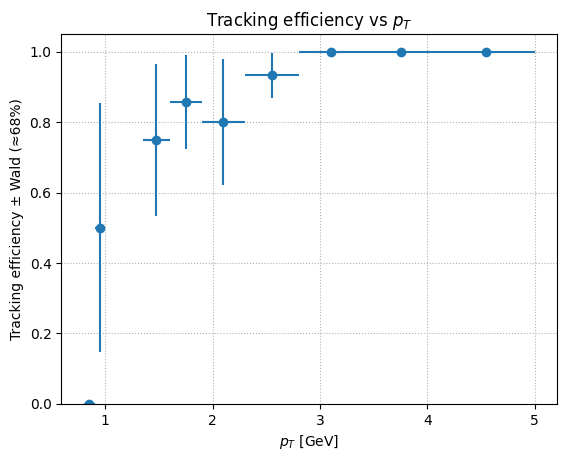

num (matched): [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 3.0, 6.0, 4.0, 14.0, 11.0, 19.0, 5.0]
den (reconstructable): [0.0, 0.0, 1.0, 2.0, 0.0, 0.0, 4.0, 7.0, 5.0, 15.0, 11.0, 19.0, 5.0]


In [360]:
plt.figure()
plt.errorbar(centers, eff, yerr=err_wald, xerr=xerr, fmt='o', linestyle='None')
plt.ylim(0, 1.05)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracking efficiency ± Wald (≈68%)")
plt.grid(True, ls=":")
plt.title(r"Tracking efficiency vs $p_T$")
plt.savefig("eff_vs_pt_wald.png", dpi=300)
plt.show()

#print("Bins (GeV):", list(zip(pt_bins[:-1], pt_bins[1:])))
print("num (matched):", num.tolist())
print("den (reconstructable):", den.tolist())
